# MNIST Handwritten Digit Classification Using Convolutional Neural Networks

## Project Category
Deep Learning / Computer Vision

---

## Objective

The objective of this project is to classify handwritten digit images from 0 to 9 using a deep learning model.

This project aims to:
- preprocess image data,
- build a Convolutional Neural Network (CNN),
- train and evaluate the model,
- analyze classification performance,
- visualize predictions and errors.

---

## Dataset Information

This project uses the MNIST handwritten digit dataset.

The dataset contains grayscale images of handwritten digits from 0 to 9.

### Dataset Details

- Image size: 28x28 pixels
- Number of classes: 10
- Training images: 60,000
- Test images: 10,000
- Classes: Digits from 0 to 9

MNIST is commonly used for deep learning and computer vision classification tasks.

---

## Algorithms and Techniques Used

- Convolutional Neural Network (CNN)
- Image Normalization
- One-Hot Encoding
- Dropout Regularization
- Confusion Matrix
- Model Evaluation

---

## Evaluation Metrics

- Accuracy
- Loss
- Confusion Matrix
- Classification Report

---

## Project Workflow

1. Data Loading
2. Data Preprocessing
3. Image Visualization
4. CNN Model Building
5. Model Training
6. Model Evaluation
7. Confusion Matrix Analysis
8. Prediction Visualization
9. Conclusion

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization)

from tensorflow.keras.utils import to_categorical

from sklearn.metrics import confusion_matrix, classification_report

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


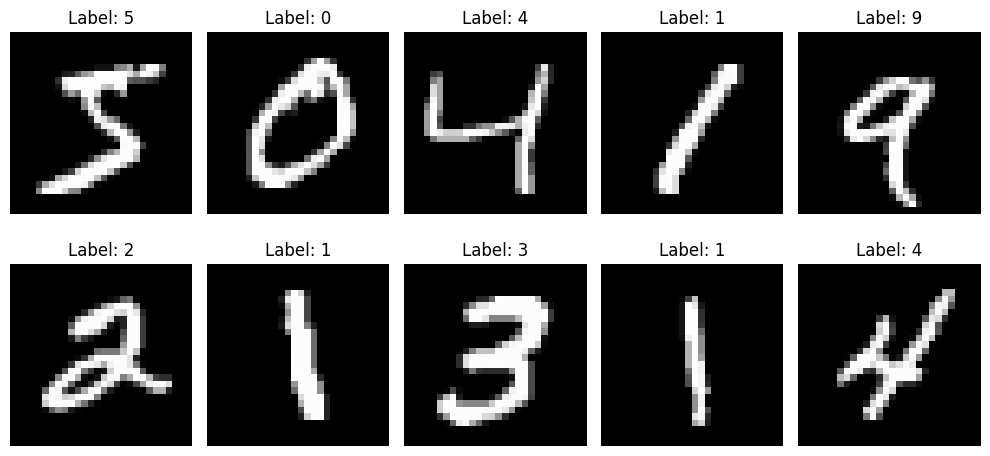

In [4]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
# Normalize pixel values
X_train = X_train / 255.0
X_test = X_test / 255.0

In [6]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [7]:
### one hot encoding

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [8]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train_cat shape:", y_train_cat.shape)
print("y_test_cat shape:", y_test_cat.shape)

X_train shape: (60000, 28, 28, 1)
X_test shape: (10000, 28, 28, 1)
y_train_cat shape: (60000, 10)
y_test_cat shape: (10000, 10)


### CNN MODEL

In [9]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation="relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128, (3,3), activation="relu"))
model.add(BatchNormalization())

model.add(Flatten())

model.add(Dense(128, activation="relu"))
model.add(Dropout(0.5))

model.add(Dense(10, activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"])


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,442 (947.04 KB)

 Trainable params: 241,994 (945.29 KB)

 Non-trainable params: 448 (1.75 KB)

In [12]:
history = model.fit(
    X_train,
    y_train_cat,
    epochs=5,
    batch_size=64,
    validation_split=0.2)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 69s 88ms/step - accuracy: 0.9500 - loss: 0.1687 - val_accuracy: 0.9833 - val_loss: 0.0556
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 83s 89ms/step - accuracy: 0.9806 - loss: 0.0674 - val_accuracy: 0.9843 - val_loss: 0.0574
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 68s 90ms/step - accuracy: 0.9858 - loss: 0.0468 - val_accuracy: 0.9866 - val_loss: 0.0500
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 81s 89ms/step - accuracy: 0.9874 - loss: 0.0413 - val_accuracy: 0.9860 - val_loss: 0.0526
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 66s 88ms/step - accuracy: 0.9889 - loss: 0.0355 - val_accuracy: 0.9884 - val_loss: 0.0450


In [13]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test_cat)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9909 - loss: 0.0302
Test Loss: 0.030152468010783195
Test Accuracy: 0.9908999800682068


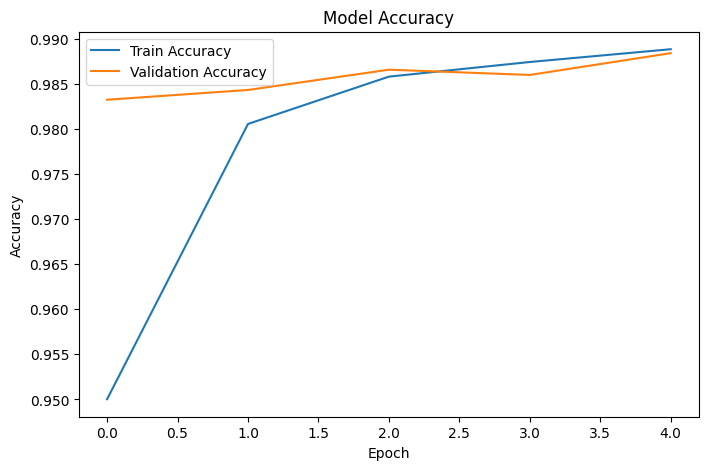

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

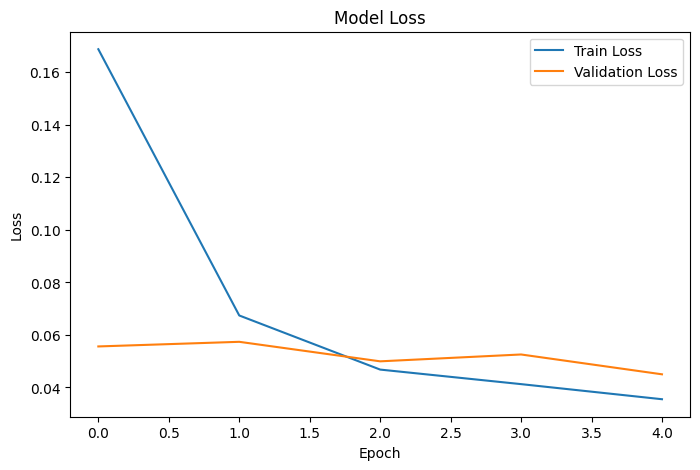

In [15]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [16]:
y_pred_probs = model.predict(X_test)

y_pred = np.argmax(y_pred_probs, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


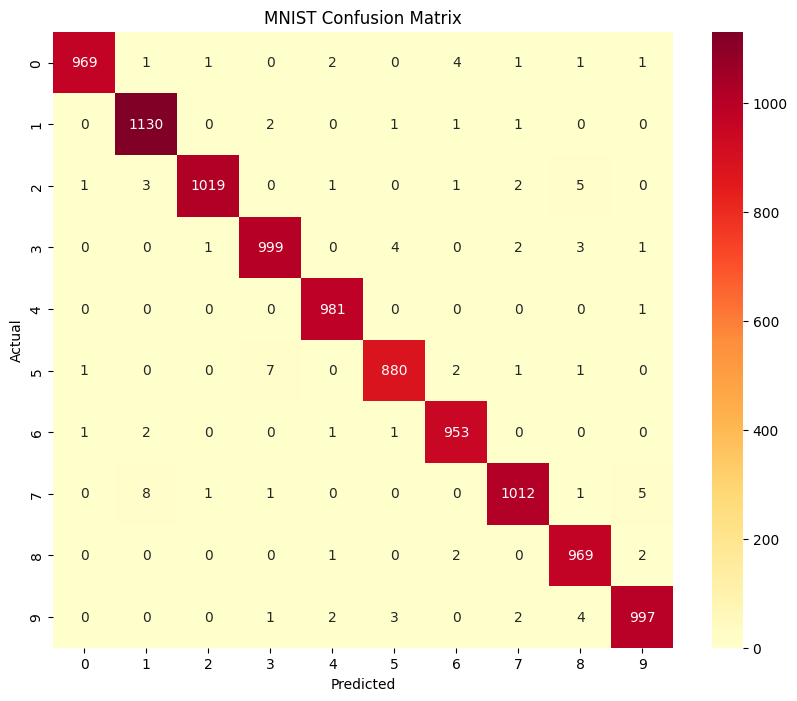

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlOrRd")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MNIST Confusion Matrix")

plt.show()

In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       980
           1       0.99      1.00      0.99      1135
           2       1.00      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      1.00      1.00       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.98      0.99      1028
           8       0.98      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



## Confusion Matrix Analysis

The confusion matrix demonstrates that the CNN model achieved highly accurate handwritten digit classification performance.

Most predictions are concentrated along the diagonal of the matrix, indicating correct digit classification.

The model successfully recognized nearly all handwritten digits from 0 to 9 with very low classification error.

A small number of misclassifications occurred between visually similar digits such as:
- 5 and 3,
- 7 and 1,
- 8 and 9.

However, the overall classification performance remained extremely strong.

The confusion matrix confirms that the CNN architecture effectively learned image patterns and digit features from the MNIST dataset.